**1) Preparation of the modeling dataset**
The aggregated approach-based count series are prepared for forecasting by selecting the traffic count variables, handling missing values, and defining sequential input-output samples.


n= total number of rows in the modeling dataset in my case 2663, dividing dataset chronologically into three parts , first 70% is my training set (1864) then my validation set, 85% 

train on earlier data
validate on later unseen data
test on the latest unseen data
****
The dataset is divided chronologically into training, validation, and test subsets. The first 70% of the observations are used for model training, the following 15% for validation during model development, and the final 15% for out-of-sample testing. This preserves the temporal order of the traffic time series and reflects the realistic forecasting setting, where future observations must not be used to train the model.

This code prepares the aggregated approach-based traffic dataset for forecasting. First, only the approach-level count variables are selected as model features. Then missing values are handled using forward filling and backward filling in order to obtain a complete multivariate time series without gaps. After that, the dataset is divided chronologically into training, validation, and test subsets. This ensures that earlier observations are used for model fitting, while later unseen observations are reserved for validation and final performance evaluation.
****
These are my 16 features:

LD-LSA16_west_count
LD-LSA16_south_count
LD-LSA16_east_count
LD-LSA16_north_count
LD-LSA10_west_count
LD-LSA10_south_count
LD-LSA10_east_count
LD-LSA10_north_west_count
LD-LSA10_north_east_count
LD-LSA9_west_count
LD-LSA9_south_count
LD-LSA9_east_count
LD-LSA9_north_west_count
LD-LSA1_west_count
LD-LSA1_east_count
LD-LSA1_north_count   , Here, the features are not detector-level values anymore.
They are your aggregated approach-level traffic counts.

The modeling dataset contains 16 input features, each representing an aggregated approach-level traffic count time series from one of the analyzed intersections. These features correspond to the selected inflow directions of LSA16, LSA10, LSA9, and LSA1 and jointly form the multivariate input for the forecasting model. (17 means timestamp + myfeatures The training dataset shape (1864, 17) means that 1864 time-indexed observations are available in the training subset and that each observation contains 17 columns in total. These columns consist of one timestamp column and 16 approach-based traffic count variables used as model features. Thus, the actual multivariate traffic input for the forecasting model has the shape (1864, 16) after excluding the timestamp column.)
****

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
APPROACH_CSV = BASE_DIR / "approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

approach_df = pd.read_csv(APPROACH_CSV)
approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], errors="coerce")
approach_df = approach_df.sort_values("timestamp_berlin").reset_index(drop=True)

# ============================================================
# SELECT FEATURES
# ============================================================

feature_cols = [col for col in approach_df.columns if col.endswith("_count")]
data = approach_df[["timestamp_berlin"] + feature_cols].copy()

print("Selected features:")
print(feature_cols)
print("\nShape before missing-value handling:", data.shape)

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

data[feature_cols] = data[feature_cols].ffill().bfill()

print("\nRemaining NaN values per feature:")
print(data[feature_cols].isna().sum())

# ============================================================
# TRAIN / VALIDATION / TEST SPLIT BY TIME
# ============================================================

n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end].copy()
val_df   = data.iloc[train_end:val_end].copy()
test_df  = data.iloc[val_end:].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())
print("Val:  ", val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())
print("Test: ", test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

Selected features:
['LD-LSA16_west_count', 'LD-LSA16_south_count', 'LD-LSA16_east_count', 'LD-LSA16_north_count', 'LD-LSA10_west_count', 'LD-LSA10_south_count', 'LD-LSA10_east_count', 'LD-LSA10_north_west_count', 'LD-LSA10_north_east_count', 'LD-LSA9_west_count', 'LD-LSA9_south_count', 'LD-LSA9_east_count', 'LD-LSA9_north_west_count', 'LD-LSA1_west_count', 'LD-LSA1_east_count', 'LD-LSA1_north_count']

Shape before missing-value handling: (2663, 17)

Remaining NaN values per feature:
LD-LSA16_west_count          0
LD-LSA16_south_count         0
LD-LSA16_east_count          0
LD-LSA16_north_count         0
LD-LSA10_west_count          0
LD-LSA10_south_count         0
LD-LSA10_east_count          0
LD-LSA10_north_west_count    0
LD-LSA10_north_east_count    0
LD-LSA9_west_count           0
LD-LSA9_south_count          0
LD-LSA9_east_count           0
LD-LSA9_north_west_count     0
LD-LSA1_west_count           0
LD-LSA1_east_count           0
LD-LSA1_north_count          0
dtype: int64

Sp

**2) Sequence generation for time series forecasting**
This step transforms the multivariate traffic time series into sequential input-output samples for one-step-ahead forecasting.

In [6]:
# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4   # previous 4 time steps = 1 hour
HORIZON = 1    # predict next 15-minute step

# ============================================================
# SCALE USING TRAIN DATA ONLY
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])

train_scaled = scaler.transform(train_df[feature_cols])
val_scaled   = scaler.transform(val_df[feature_cols])
test_scaled  = scaler.transform(test_df[feature_cols])

# ============================================================
# CREATE SEQUENCES
# ============================================================

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
X_val, y_val     = create_sequences(val_scaled, LOOKBACK, HORIZON)
X_test, y_test   = create_sequences(test_scaled, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
print("X_test: ", X_test.shape, "y_test:", y_test.shape)

X_train: (1860, 4, 16) y_train: (1860, 16)
X_val:   (395, 4, 16) y_val: (395, 16)
X_test:  (396, 4, 16) y_test: (396, 16)


**3) Naive persistence baseline**
Naive: the next 15-minute traffic count will be the same as the most recent observed 15-minute traffic count.

The naive baseline predicts that the next traffic state is equal to the most recent observed state.


In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ============================================================
# NAIVE BASELINE
# ============================================================

y_pred_naive_scaled = X_test[:, -1, :]

# inverse transform to original scale
y_test_actual = scaler.inverse_transform(y_test)
y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
overall_rmse_naive = rmse(y_test_actual, y_pred_naive_actual)

print("Naive baseline performance:")
print("Overall MAE :", round(overall_mae_naive, 3))
print("Overall RMSE:", round(overall_rmse_naive, 3))

Naive baseline performance:
Overall MAE : 8.847
Overall RMSE: 17.014


**Naive persistence baseline**

The naive baseline predicts the next 15-minute traffic state by assuming that it is equal to the most recent observed state. In other words, the last available traffic count is directly used as the forecast for the next time step. This persistence-based method provides a simple but strong benchmark for short-term traffic forecasting. Its performance is evaluated using MAE and RMSE, which later allows a direct comparison with the LSTM model.

Length of test_timestamps: 396
Length of y_test_actual: 396
Length of y_pred_naive_actual: 396


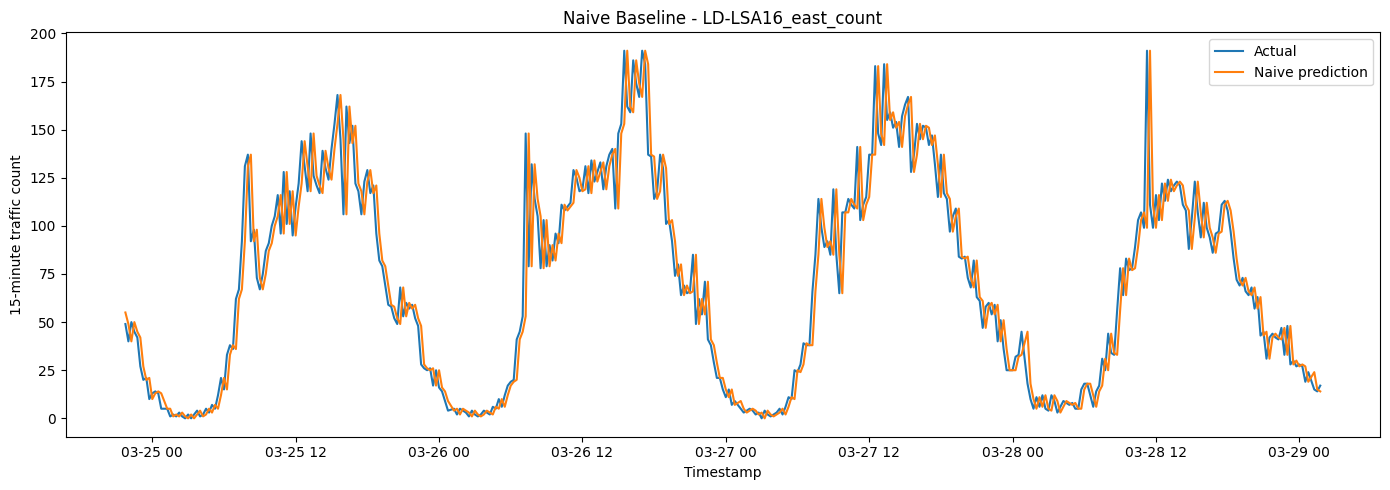

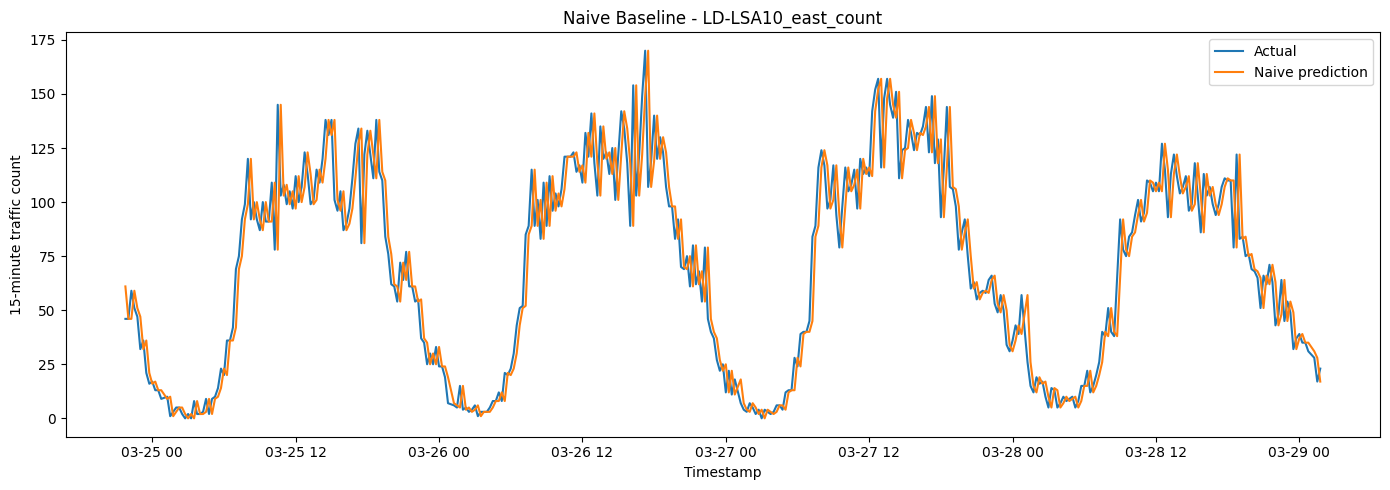

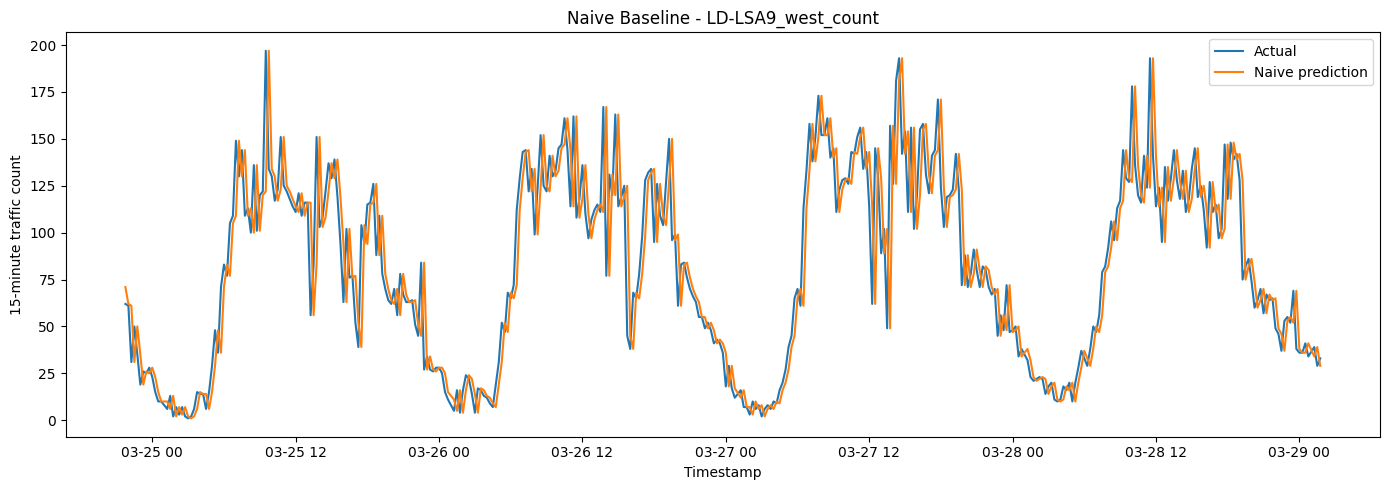

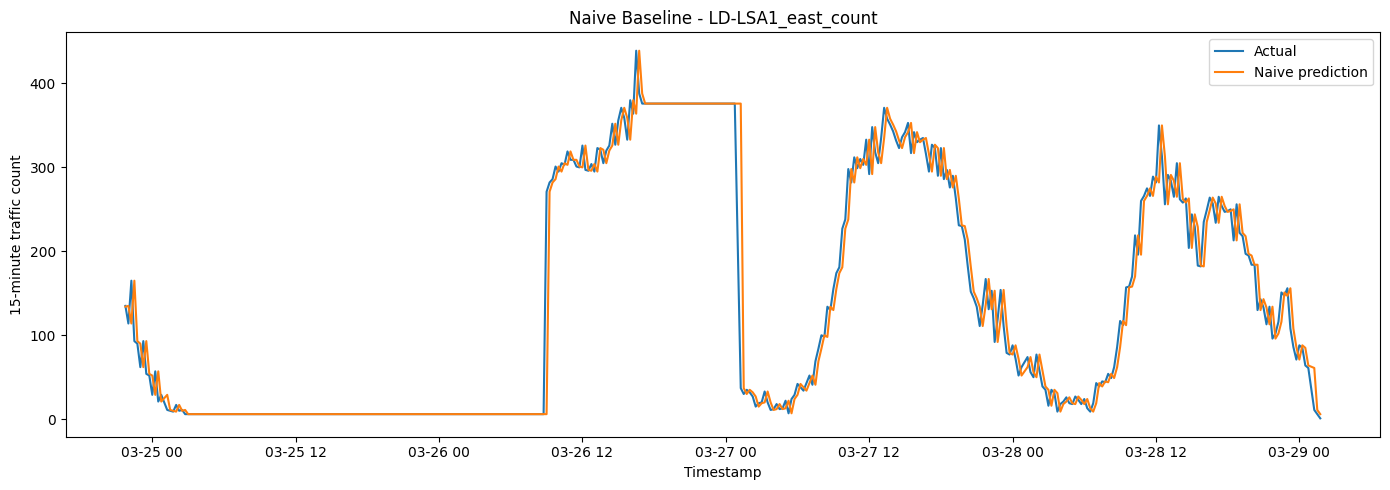

In [8]:
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4
HORIZON = 1

plot_features = [
    "LD-LSA16_east_count",
    "LD-LSA10_east_count",
    "LD-LSA9_west_count",
    "LD-LSA1_east_count",
]

# timestamps aligned with y_test
test_timestamps = test_df["timestamp_berlin"].iloc[LOOKBACK + HORIZON - 1:].reset_index(drop=True)

print("Length of test_timestamps:", len(test_timestamps))
print("Length of y_test_actual:", len(y_test_actual))
print("Length of y_pred_naive_actual:", len(y_pred_naive_actual))

for feature in plot_features:
    if feature not in feature_cols:
        continue

    idx = feature_cols.index(feature)

    plt.figure(figsize=(14, 5))
    plt.plot(test_timestamps, y_test_actual[:, idx], label="Actual")
    plt.plot(test_timestamps, y_pred_naive_actual[:, idx], label="Naive prediction")

    plt.title(f"Naive Baseline - {feature}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.tight_layout()
    plt.show()

The comparison between observed traffic counts and naive baseline predictions shows that the naive model closely follows the actual time series with a slight temporal delay. Since the naive approach assumes that the next value is equal to the most recent observation, it effectively shifts the time series by one time step.

As a result, the predicted values capture the overall trend and shape of the traffic dynamics, including peaks and declines, but cannot anticipate sudden changes. This is particularly visible at points where traffic demand increases or decreases rapidly, where the naive model reacts one time step too late.

Overall, the naive baseline provides a strong benchmark for short-term forecasting, as it performs well in stable conditions but lacks the ability to predict turning points in traffic flow.

In [9]:
sample_idx = 0
feature_name = "LD-LSA16_east_count"
feature_idx = feature_cols.index(feature_name)

print("Feature:", feature_name)
print("Last observed value in input sequence:",
      scaler.inverse_transform(X_test[sample_idx])[-1, feature_idx])

print("Naive predicted next value:",
      y_pred_naive_actual[sample_idx, feature_idx])

print("Actual next value:",
      y_test_actual[sample_idx, feature_idx])

Feature: LD-LSA16_east_count
Last observed value in input sequence: 54.99999999999999
Naive predicted next value: 54.99999999999999
Actual next value: 49.0


MAE ≈ 8.8 is actually quite good, naive captures trend, peaks, overallstructure but fails at turning points i mean the peak hours, sharp changes etc
LSTM must beat this → otherwise not useful, The naive baseline demonstrates strong performance due to the temporal continuity of traffic flow, but it consistently lags behind during periods of rapid change, highlighting the need for more advanced models capable of capturing dynamic temporal dependencies.